# Checkerboard data analysis

Contact: laquitainesteeve@gmail.com based on Guilhelm's guilhelm-dev branch  

Description: This notebook is the second one of the Analysis Pipeline. If you haven't run the first one (Preprocessing) until the extraction of phy's data , you don't have the files needed to run this one. In this notebook, you will use phy sorted cluster spikes of a checkerboard recording to compute clusters raster plots, ganglion cells STA and fit ellipses on their receptive fields.

Execution time: <15 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**Requirements:**
- Run preprocessing before

**Required by**:
- 4-Chirp+Cell Typing.ipynb notebook

## Setup

1. Create, activate (env/..yml) and setup the virtual environment :

    ```python
    python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"
    ```

2. Configure your experiment in ./params.py

In [1]:
!python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"

Installed kernelspec standard_analysis_pipeline in C:\Users\cboscarino\AppData\Roaming\jupyter\kernels\standard_analysis_pipeline


In [2]:
%reload_ext autoreload
%autoreload 2

# import packages
import os
import utils

# import custom packages
import params
import analyse_checkerboard_steeve as analysis

c:\Users\cboscarino\Documents\GitHub\Standard_analysis_pipeline\env\standard_analysis_pipeline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



-------- Creating all paths ---------

- "Sorting" path already exists
- "output" path already exists
- "triggers" path already exists


## Load data

- All the variables used in this part of the cell should always refer to your 'params.py' file, unless you want to manually change them only for this run (i.e. debugging). You may have to add those variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
- Mandatory for each run !
- Execution time: 9 secs

In [3]:
%%time 
load_only_params = False

# ask user to input the experiment parameters
# e.g., for the test dataset enter inputs: 0, 30, 42, 42
(
    recording_number,
    recording_name,
    stimulus_frequency,
    nb_checks_x,
    nb_checks_y,
    check_directory,
) = analysis.get_all_inputs_for_checkerboard_analysis(params)

# load checkerboard experiment data
if not load_only_params:
    checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard = (
        analysis.load_checkerboard_data(
            params,
            check_directory,
            recording_name,
            nb_checks_x,
            nb_checks_y,
            stimulus_frequency,
        )
    )

Which of the following is the checkerboard: 
	0 --> 00_AccCheck_30Hz_16px_42sq_50%30ND
	1 --> 01_Swn_30Hz_48pxCh_6pxL_50%30ND
	2 --> 02_Chirp_50Hz_50%30ND
	3 --> 03_DG_50Hz_50%30ND
	4 --> 04_PulsingGratings-PS0_40Hz_50%30ND
	5 --> 05_PulsingGratings-PS1_40Hz_50%30ND
	6 --> 06_PulsingGratings-PS2_40Hz_50%30ND
Selected recording: 00_AccCheck_30Hz_16px_42sq_50%30ND

Creating analysis directory...
./data/20251219_PulsingGratings_PupilSize\Analysis
./data/20251219_PulsingGratings_PupilSize\Analysis\triggers
Loading triggers from:	 data\20251219_PulsingGratings_PupilSize\Analysis\triggers\20251219_PulsingGratings_PupilSize_00_AccCheck_30Hz_16px_42sq_50%30ND_triggers.pkl
Total triggers number : 66728
Triggers type loaded : visual

Checkerboard Stats :
	- 37 min total duration
	- 66728 triggers
	- 55 complete sequences
	- 40 seconds per sequence

Stimulus file exists. Loaded from:	 data\20251219_PulsingGratings_PupilSize\Analysis\Checkerboard_Analysis_rec_0\checkerboard_42x42checks_33000frames

## Extract responses to repeated sequence (raster plot and psth)

- Analysis on repeated sequence: all the variables used in this part of the cell should always refere to your 'params.py' file
unless you want to manually change them only for this run (i.e. debugging). 
You may have to add those variable into the function you want to adapt as only the minimal 
amount of var are currently given to functions as inputs.
- Requirements: cell 1 run
- Execution time: < 3 mins

In [4]:
%%time

# inputs
save_data = True # save data or not
show_all_rasters = False # show all rasters in one figure in console or not (might take couple of seconds)
save_single_cell_figures = False  # compute and save one figure per cell showing raster+psth or not (might take couple of seconds) 

# extract data
rep_seq_data = analysis.extract_all_cell_responses_to_repeated_sequences(
    checkerboard_spikes, 
    triggers, 
    nb_repeats, 
    stimulus_frequency, 
    cells_id,
    nb_frames_per_sequence=params.nb_frames_by_sequence,
    sequence_portion=(0.5, 1),
)
if save_data: 
    utils.save_obj(rep_seq_data, os.path.join(check_directory, "Check_rasters_data"))

# plot data
if show_all_rasters: 
    analysis.plot_all_rasters(rep_seq_data, cells_id)
if save_single_cell_figures:
    analysis.plot_and_save_single_cell_rasters(
        rep_seq_data, 
        cells_id, 
        check_directory, 
        title="Response to repeated sequence")

Extracting responses to repeated sequence for each cell: 100%|██████████| 344/344 [00:00<00:00, 370.97it/s]


CPU times: total: 1.23 s
Wall time: 1.21 s


## Compute STAs

- **Requirements**: requires cell 1 run
- Execution time: < 5 min

In [ ]:
%%time 

# Extract responses to non-repeated sequences, compute STA and save data
sta_data_file, sta_data = analysis.compute_spike_triggered_average(
    checkerboard_spikes,
    checkerboard,
    triggers,
    nb_repeats,
    stimulus_frequency,
    check_directory,
    temporal_dimension=params.sta_temporal_dimension,
    sequence_portion=(0, 0.5),
    nb_frames_per_sequence=params.nb_frames_by_sequence,
    sta_data_filename="sta_data_3D.pkl",
)

Computing STAs...


  8%|▊         | 28/344 [00:58<10:54,  2.07s/it]

Cell 28 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 16%|█▋        | 56/344 [02:01<10:44,  2.24s/it]

Cell 56 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 69%|██████▊   | 236/344 [08:53<03:55,  2.18s/it]

### Or load existing ones

In [ ]:
%%time

# RUN THIS CELL ONLY IF STA DATA HAS BEEN ALREADY COMPUTED AND SAVED AND YOU JUST WANT TO LOAD IT TO RUN FOLLOWING ANALYSIS, 
# OTHERWISE RUN THE PREVIOUS CELL TO COMPUTE AND SAVE THE STA DATA
# load sta data if not computed and already available
load_sta_data = True
sta_data_file = os.path.join(check_directory, "sta_data_3D.pkl")
if load_sta_data and os.path.exists(sta_data_file):
    sta_data = utils.load_obj(sta_data_file)

CPU times: total: 344 ms
Wall time: 333 ms


### Visualize example 3D STA 

- execution time: 5 secs

Total : 344 cells found
Cell ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...


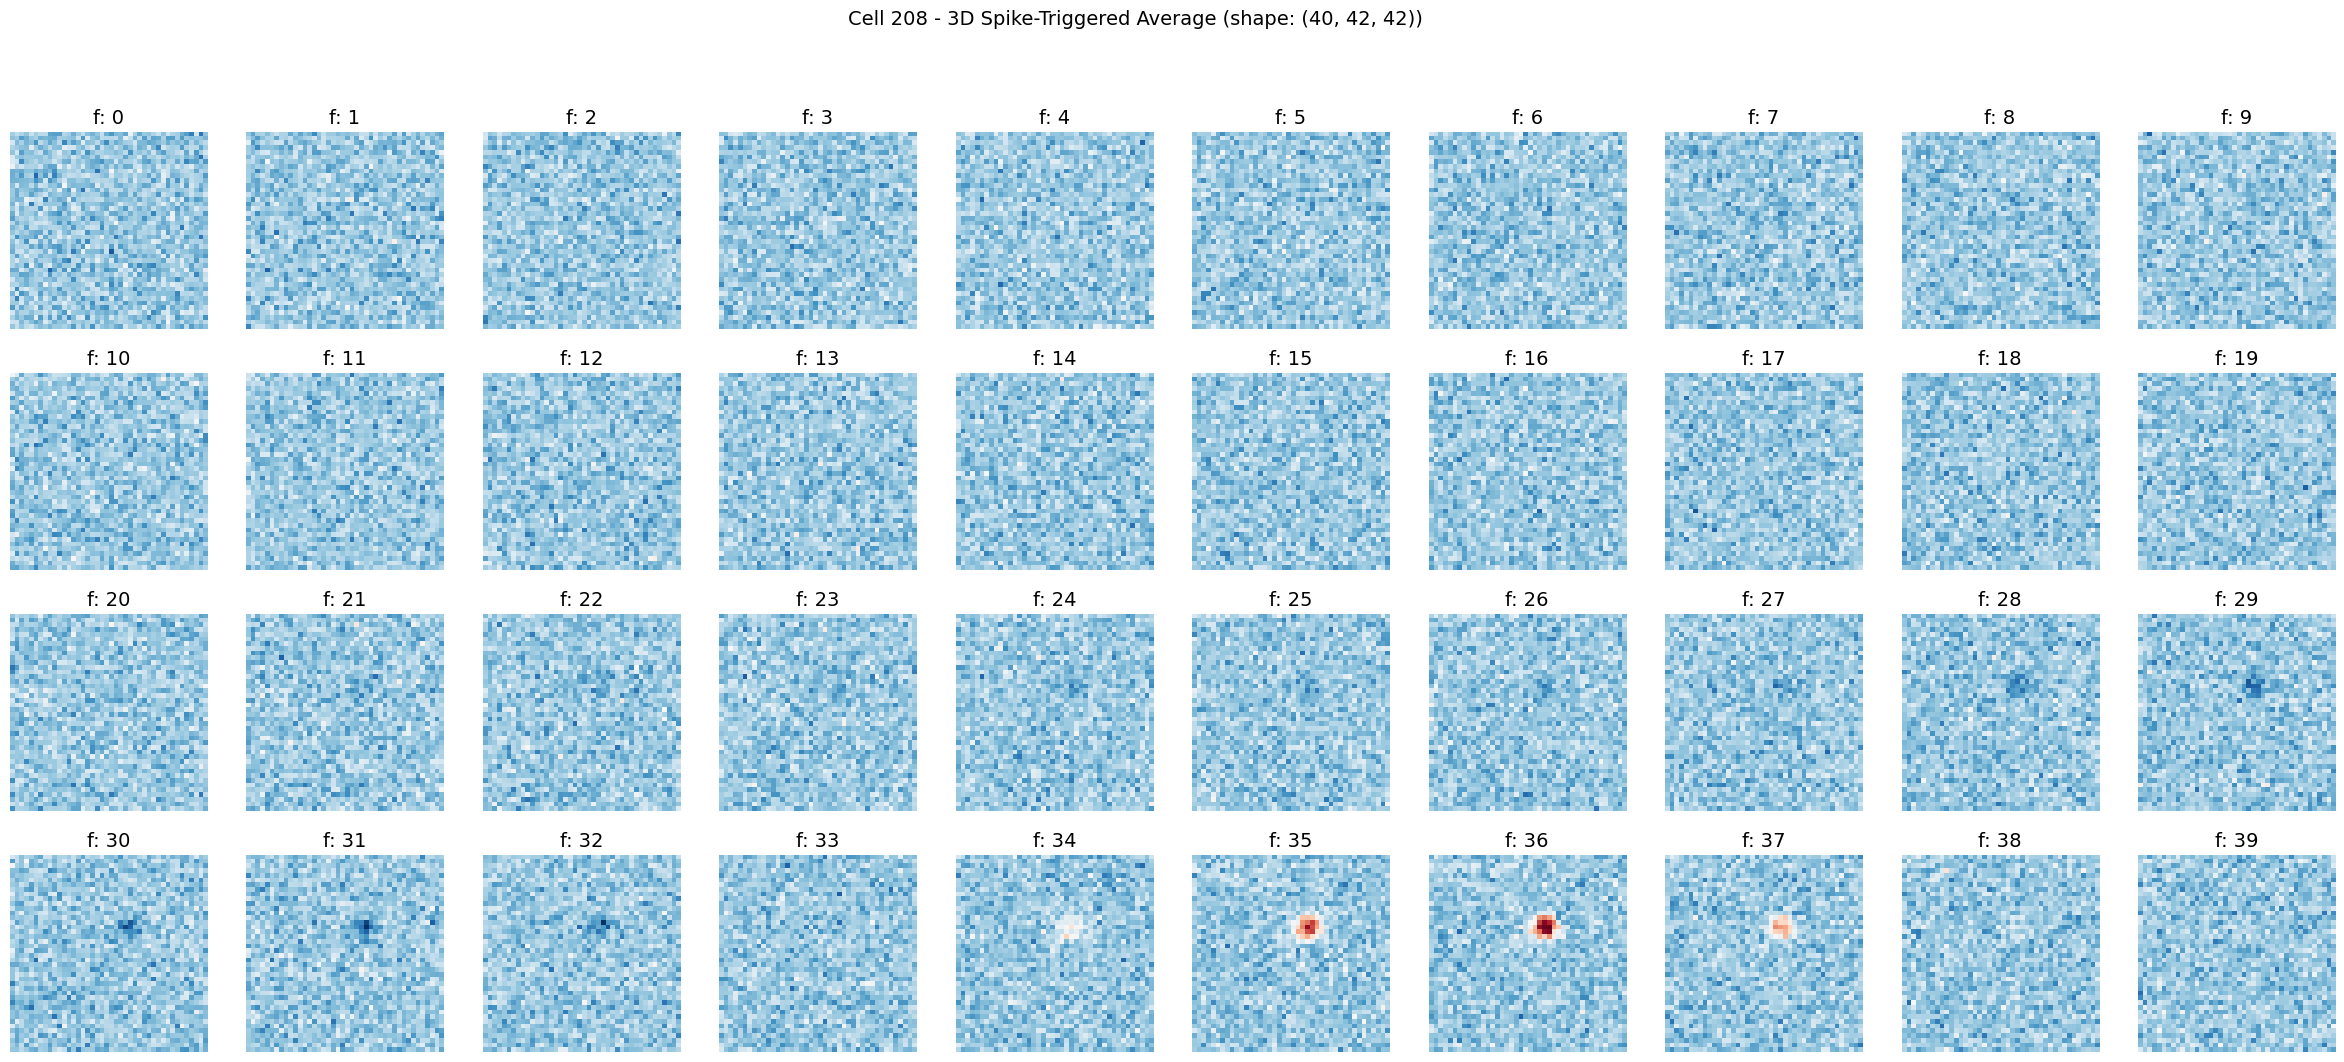

CPU times: total: 2.08 s
Wall time: 4.98 s


In [12]:
%%time 

# ask the user to input a cell and plot its 3D sta (e.g., 1)
analysis.plot_one_cell_3D_spike_triggered_average(
    sta_data, 
    max_frames_to_show=params.sta_temporal_dimension,
    n_frames_per_line=10,
    fontsize=14)

## Analyse STAs to identify receptive fields

- **Requirements**: requires cell 1 run and cell 4 output
- Execution time: 10 secs

Plotting STAs for all cells: 100%|██████████| 361/361 [00:00<00:00, 535.09it/s] 



Spatial STAs for 344 cells
340 fitted ellipse (green), 4 failed ellipse fitting (red)


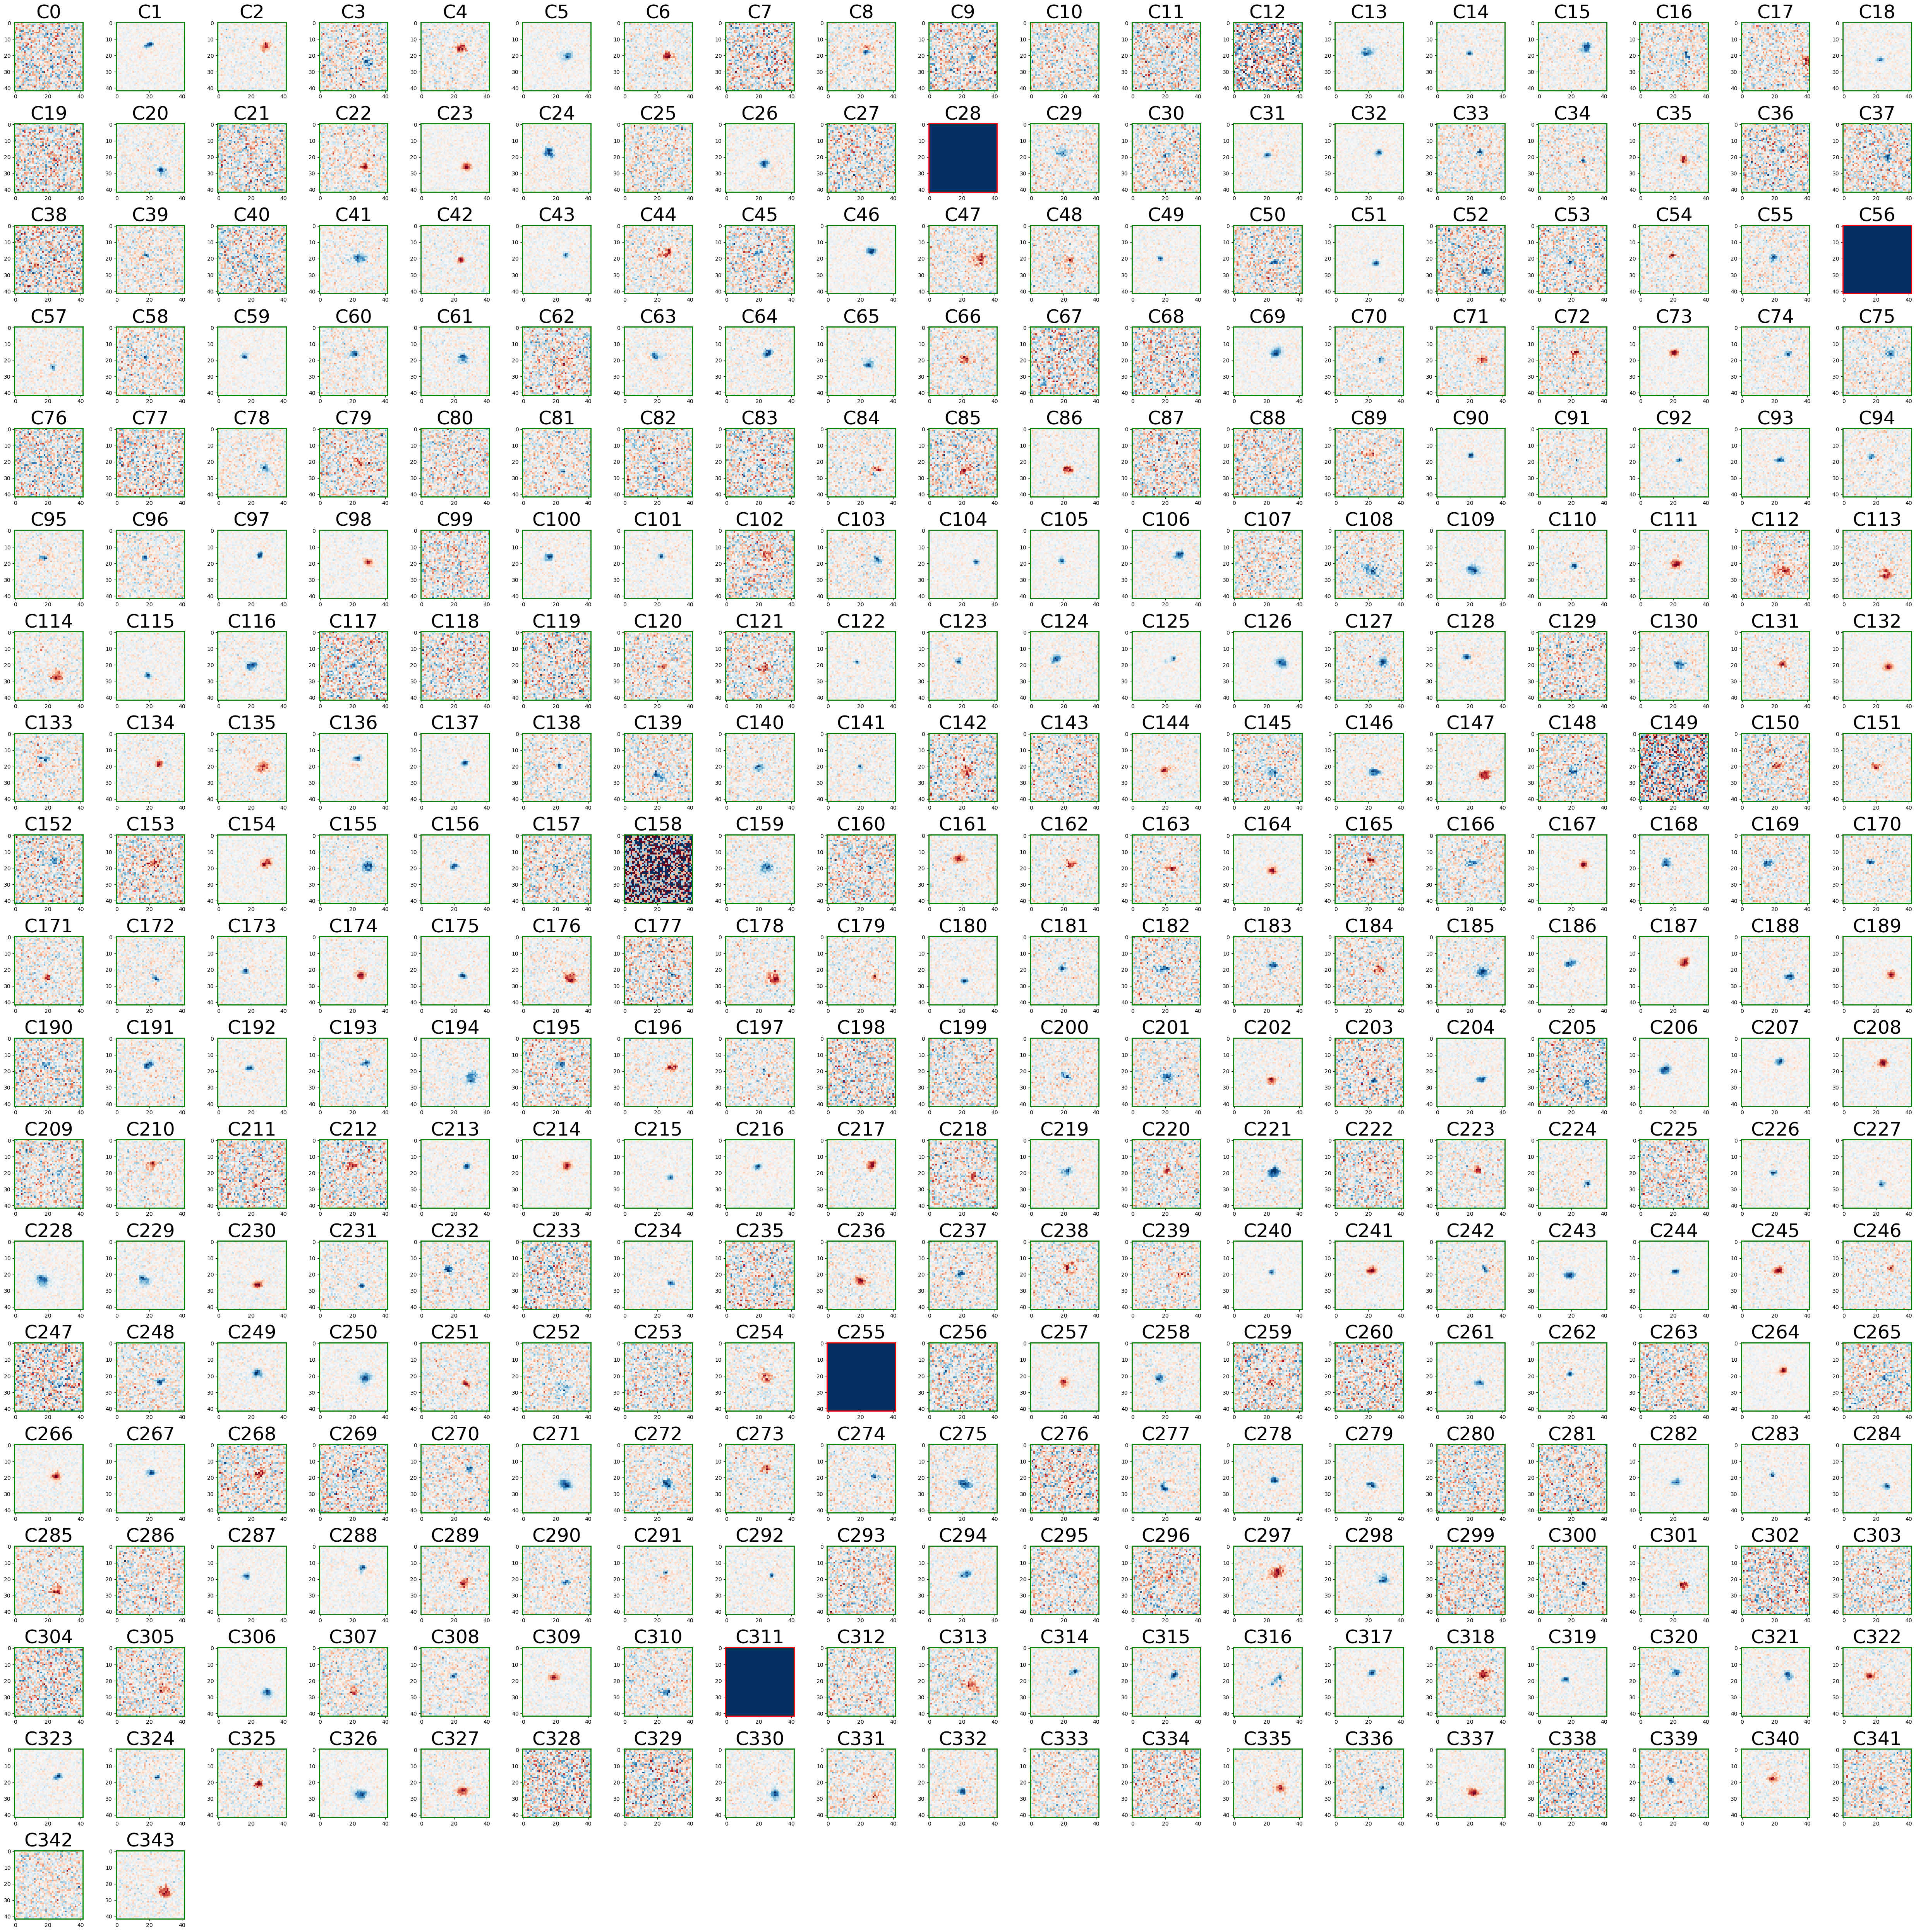

CPU times: total: 1min 15s
Wall time: 1min 18s


In [ ]:
%%time 

show_all_stas = True

# Analyze STAs to extract receptive field properties for all cells, 
# add it to the sta_data dictionary and save it
sta_data_analysed = analysis.analyse_all_stas(
    sta_data, 
    directory=check_directory,
    data_filename="sta_data_analysed.pkl",
    method="guilhem"
)

if show_all_stas:
    analysis.plot_all_stas(sta_data_analysed)

## Visualize receptive fields 

- Check the figure saved in the Analysis/ folder.
- Execution time: 30 secs

In [ ]:
%%time

# Re-loading analysed STA data if already computed and saved, 
# to run following analysis without re-computing it
# - False if you run the previous cell to compute the analysed STA data, so it is already in memory
# - True if you just want to run following analysis and the analysed STA data has already been computed and saved
load_sta_data = False
if load_sta_data:
    sta_data_analysed_file = os.path.join(check_directory, "sta_data_analysed.pkl")
    if os.path.exists(sta_data_analysed_file):
        sta_data_analysed = utils.load_obj(sta_data_analysed_file)

# Plotting STAs & their fitted ellipses for all cells 
analysis.plot_sta_fitted_with_ellipse(
    sta_data_analysed, 
    check_directory
)

Generating STA and ellipse fitting figures for each cell: 100%|██████████| 344/344 [02:55<00:00,  1.95it/s]

CPU times: total: 2min 39s
Wall time: 2min 55s


## Plotting STAs & their fitted ellipses (New proposition by Tom)

- [steeve] idem as previous cell
- Execution time: 11 secs

In [ ]:
%%time

# Plotting STAs & their fitted ellipses (New proposition by Tom)
analysis.plot_sta_fitted_with_ellipse_by_tom(
    rep_seq_data, cells_id, cells_to_plot=[0, 1], check_directory=check_directory
)

# Quantification of the number of STAs (not needed in the standard pipeline)

- [steeve] if not needed, I ignore this.

In [ ]:
# #The Goal of this cell is to quantify the number of STAs in your data
# #Tuned to a 40x40 with square of 15 pixels checkerboard.
# #Maybe, you need to tune it for your specific checkerboard
# #See with Tom Quetu if needed for the tuning

# print('')
# nb_of_pixels_by_check = int(input("Select number of pixels by checks : "))

# sta_data=np.load(os.path.join(check_directory,'sta_data_3D_fitted.pkl'),allow_pickle=True)
# sta_quantification_dict={}

# for cell in tqdm(cells_id[0:]):
#     fig, ax = plt.subplots(nrows = 1,ncols = 1, figsize=(7,7))

#     plt.suptitle(f'Cell {cell}')

#     sta_spatial=sta_data[cell]["center_analyse"]['Spatial']
#     ellipse_coor=sta_data[cell]["center_analyse"]['EllipseCoor']

#     sta_quantification=check_presence_STA(sta_spatial,ellipse_coor,nb_of_pixels_by_check,tresh_snr=2.75)

#     try:
#         ax = plot_sta_tom(ax, sta_spatial,ellipse_coor)
#     except:
#         ax.imshow(sta_spatial)

#     color_cadr='r'
#     if sta_quantification[0]==1:
#         color_cadr='g'
#         ax.set(title='STA with a SNR of ' + str(sta_quantification[1]))
#     elif sta_quantification[0]==0.1:
#         ax.set(title='ellipse not centered')
#     elif sta_quantification[0]==0.2:
#         ax.set(title='no ellipse fitted')
#     elif sta_quantification[0]==0.3:
#         ax.set(title='diameter too big or too small, diameter: ' + str(sta_quantification[1]) +'µm')
#     elif sta_quantification[0]==0.4:
#         ax.set(title='No STA because the SNR is too small, SNR:' + str(sta_quantification[1]))

#     ax.spines['top'].set(lw=6, color=color_cadr)
#     ax.spines['bottom'].set(lw=6, color=color_cadr)
#     ax.spines['left'].set(lw=6, color=color_cadr)
#     ax.spines['right'].set(lw=6, color=color_cadr)

#     sta_quantification_dict[cell]=sta_quantification[0]
#     plt.show()
#     plt.close()

# sta_quantif_dir=check_directory+'/sta_quantification'
# save_obj(sta_quantification_dict,sta_quantif_dir)

# --------- end of the notebook---------------------------------------

# -----------work in progress---------------

### Cell 7 : Compare fits - Spatial STA

In [ ]:
# """
#     Variable

#     You will find here all variables used in this notebook cell. They should always refere to your 'params.py' file
#     except if you want to manually change some variable only for this run (i.e. debugging). You may have to add those
#     variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
# """

# output_directory = params.output_directory

# """
#     Input
# """
# # path = 'E:\Exp_17_for benchmark\RF_m1'


# fitted_file = os.path.normpath(os.path.join(output_directory,'sta_data_3D_fitted.pkl'))

# """
#     Processing
# """

# sta_data = load_obj(fitted_file)

# for cell_id in sta_data.keys():
#     fig = plt.figure(figsize=(12,3))
#     plt.subplots_adjust()
#     fig.suptitle(f'Cell : {cell_id}')
#     gs = GridSpec(1, 4, figure=fig)

# #     png_image = np.array(Image.open(os.path.normpath(os.path.join(path,r'exp17_m1_clus{}_RF_STA_check.png'.format(cell_id)))))[74:472,132:530].transpose(1,0,2)
#     matias  = sta_data[cell_id]["center_analyse"]
# #     gabriel = sta_data[cell_id]["surround_analyse"]
#     mixed   = sta_data[cell_id]["analyse_sta"]

#     try:
# #         ax1 = fig.add_subplot(gs[0,0])
# #         ax1.imshow(png_image)
# #         ax1.set_title('Matlab')

#         ax2 = fig.add_subplot(gs[0,1])
#         ax2 = plot_sta(ax2, matias['Spatial'],matias['EllipseCoor'])
#         ax2.set_title('Matias')

# #         ax3 = fig.add_subplot(gs[0,2])
# #         ax3 = plot_sta(ax3, matias['Spatial'],gabriel['EllipseCoor'])
# #         ax3.set_title('Gabriel')

#         ax4 = fig.add_subplot(gs[0,3])
#         ax4 = plot_sta(ax4, mixed['Spatial'],mixed['EllipseCoor'])
#         ax4.set_title('Mixed')


#     except:
#         print(f'No print for cell {cell_id}')
#         pass
#     m=matias['EllipseCoor']
# #     g=gabriel['EllipseCoor']
#     mixed = mixed['EllipseCoor']
#     print(f'matias : {m}')
# #     print(f'gabriel : {g}')
#     print(f'mixed : {mixed}')
#     plt.show(block=False)

#     print('--- Ploting Done ---')

In [ ]:
# cell_id = 30

# png_image = np.asarray(Image.open(os.path.normpath(os.path.join(path,r'exp17_m1_clus{}_RF_STA_check.png'.format(cell_id)))))[74:472,132:530].transpose(1,0,2)
# matias  = sta_data[cell_id]["center_analyse"]
# gabriel = sta_data[cell_id]["surround_analyse"]
# mixed   = sta_data[cell_id]["analyse_sta"]

# fig = plt.figure(constrained_layout=True, figsize=(12,3))
# gs = GridSpec(1, 4, figure=fig, wspace = 0)

# ax1 = fig.add_subplot(gs[0,0])
# ax1.imshow(png_image)
# ax1.set_title('Matlab')

# ax2 = fig.add_subplot(gs[0,1])
# ax2 = plot_sta(ax2, matias['Spatial'],matias['EllipseCoor'])
# ax2.set_title('Matias')

# ax3 = fig.add_subplot(gs[0,2])
# ax3 = plot_sta(ax3, gabriel['Spatial'],gabriel['EllipseCoor'])
# ax3.set_title('Gabriel')

# ax4 = fig.add_subplot(gs[0,3])
# ax4 = plot_sta(ax4, mixed['Spatial'],mixed['EllipseCoor'])
# ax4.set_title('Mixed')

# m=matias['EllipseCoor']
# g=gabriel['EllipseCoor']
# mixed = mixed['EllipseCoor']

# print(f'matias : {m}')
# print(f'gabriel : {g}')
# print(f'mixed : {mixed}')

# plt.show(block=False)

### Cell 8 : Compare fit - Temporal STA

In [ ]:
# """
#     Variable

#     You will find here all variables used in this notebook cell. They should always refere to your 'params.py' file
#     except if you want to manually change some variable only for this run (i.e. debugging). You may have to add those
#     variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
# """

# output_directory = params.output_directory

# """
#     Input
# """

# # path = 'E:\Exp_17_for benchmark\RF_m1'
# fitted_file = os.path.normpath(os.path.join(output_directory,'sta_data_3D_fitted.pkl'))

# """
#     Processing
# """

# sta_data = load_obj(fitted_file)

# for cell_id in sta_data.keys():

#     fig = plt.figure(figsize=(9,3))
#     plt.subplots_adjust()
#     fig.suptitle(f'Cell : {cell_id}')
#     gs = GridSpec(1, 3, figure=fig)

#     matias  = sta_data[cell_id]["center_analyse"]
# #     gabriel = sta_data[cell_id]["surround_analyse"]
#     mixed   = sta_data[cell_id]["analyse_sta"]

#     try:
#         ax1 = fig.add_subplot(gs[0,0])
#         ax1.plot(matias['Temporal'])
#         ax1.axvline(matias['Cell_delay'])
#         ax1.set_title('Matias')

# #         ax2 = fig.add_subplot(gs[0,1])
# #         ax2.plot(gabriel['Temporal'])
# #         ax2.axvline(gabriel['Cell_delay'])
# #         ax2.set_title('Gabriel')

#         ax3 = fig.add_subplot(gs[0,2])
#         ax3.plot(mixed['Temporal'])
#         ax3.axvline(mixed['Cell_delay'])
#         ax3.set_title('Mixed')


#     except:
#         print(f'Print failed for cell {cell_id}')
#         pass

#     m=matias['EllipseCoor']
# #     g=gabriel['EllipseCoor']
#     mixed = mixed['EllipseCoor']

#     print(f'matias : {m}')
# #     print(f'gabriel : {g}')
#     print(f'mixed : {mixed}')
#     plt.show(block=False)
